## **Gradient Descent visualization**

Text from *Machine Learning Specialization*

In machine learning *gradient descent* is described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.datasets import load_diabetes

In [461]:
x1 = np.linspace(-3,3,30)
y = x1*2 +1

#### Defining the grid params, aiming to have convex shape

In [332]:
b_range = np.linspace(-20, 20, 30)
w_range = np.linspace(-20, 20, 30)

In order to calculate Cost function, I need to care about multiplication of dimensions:

$$ y^T \in \mathbb{R}^{m \times m \times n} $$

Key Rules for Broadcasting ( by NumPy documentation):

**1**) Dimension Alignment: Shapes are compared from the trailing (rightmost) dimensions, moving forward.

**2**) Compatibility: Dimensions are compatible if they are equal, or if one of them is 1.

**3**) Expansion: If a dimension is 1, it is stretched (broadcast) to match the corresponding dimension of the other array.

In [462]:
class Round1():
    def __init__(self,x,y,w,b):
        self.x=x
        self.y=y
        self.w=w
        self.b=b
        self.m = len(w)
        self.n = len(x)
    def meshgrid(self):
        B,W = np.meshgrid(self.b,self.w)
        return B,W
    def pre_calculation(self):
        """ Preparing the data for arithemtic computation"""
        B,W = self.meshgrid()

        # Dynamic reshape here:
        B_3d = B.reshape(self.m,self.m,1)
        W_3d = W.reshape(self.m,self.m,1)
        X_3d = self.x.reshape(1,1,self.n)
        Y_3d = self.y.reshape(1,1,self.n)
        return B_3d,W_3d,X_3d,Y_3d
    
    def get_cost(self):
        b,w,x,y = self.pre_calculation()
        pred = w*x + b
        residuals = (y-pred)**2
        cost = 1/(2*self.n)*np.sum(residuals**2,axis=2)
        return cost
    def plot3d(self):
        B,W = self.meshgrid()
        cost_values = self.get_cost()
        fig= plt.figure(figsize=(12,8))
        ax = fig.add_subplot(111,projection='3d')
        ax.plot_surface(B,W,cost_values)
        ax.view_init(25,25)
        plt.show()

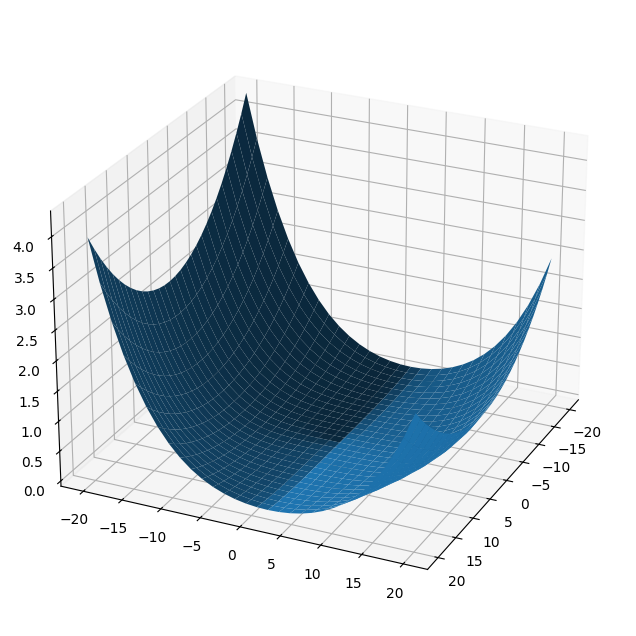

In [463]:
r = Round1(x1,y,w_range,b_range)
r.meshgrid()
r.pre_calculation()
r.get_cost()
r.plot3d()

### Implementing Gradient Descent


Conventions:
- The naming of python variables containing partial derivatives follows this pattern,$\frac{\partial J(w,b)}{\partial b}$  will be `dj_db`.
- w.r.t is With Respect To, as in partial derivative of $J(wb)$ With Respect To $b$.

In [470]:
def compute_gradient(x,y,w,b):
  """
  Computes the gradient for linear regression 
  """
  # Gradient of b defined as convention: dj_db 
  # Gradient of w defined as convention: dj_dw 

  dj_db = 1/len(x)*np.sum(np.dot(w,x)+b - y)
  dj_dw = 1/len(x)*np.sum(np.dot(w,x)+b -y)*x.T
  return(dj_db,dj_dw)

In [471]:
compute_gradient(x1,y,w_range,b_range)

(np.float64(640.3793103448277),
 array([-1921.13793103, -1788.64565993, -1656.15338882, -1523.66111772,
        -1391.16884661, -1258.67657551, -1126.1843044 ,  -993.69203329,
         -861.19976219,  -728.70749108,  -596.21521998,  -463.72294887,
         -331.23067776,  -198.73840666,   -66.24613555,    66.24613555,
          198.73840666,   331.23067776,   463.72294887,   596.21521998,
          728.70749108,   861.19976219,   993.69203329,  1126.1843044 ,
         1258.67657551,  1391.16884661,  1523.66111772,  1656.15338882,
         1788.64565993,  1921.13793103]))